## Ran Uram  
## Shahar Lankry  
## Daniel Geron 
-------------------------

## Importing Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import cv2
import os
from tqdm import tqdm
import collections
import numpy as np
import urllib.request
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dropout, Flatten, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from keras.layers import Conv2D, MaxPooling2D, Activation, Dense, Flatten
from sklearn import metrics
import seaborn as sns

## Importing data

In [ ]:
data_dir =#path to the dataset saved locally
X=[]
Y=[]
for subdir in os.listdir(data_dir):
    if subdir=="Blank":
        continue
    subdir_path = os.path.join(data_dir, subdir)
    if os.path.isdir(subdir_path):
        filenames= os.listdir(subdir_path)
        for filename in filenames: 
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(subdir_path, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    X.append(img)
                    Y.append(subdir)
        print(f"finished putting labels for {subdir}")

print(f"Total images loaded: {len(X)}")
print(f"Total labels loaded: {len(Y)}")


finished putting labels for A
finished putting labels for B
finished putting labels for C
finished putting labels for D
finished putting labels for E
finished putting labels for F
finished putting labels for G
finished putting labels for H
finished putting labels for I
finished putting labels for J
finished putting labels for K
finished putting labels for L
finished putting labels for M
finished putting labels for N
finished putting labels for O
finished putting labels for P
finished putting labels for Q
finished putting labels for R
finished putting labels for S
finished putting labels for T
finished putting labels for U
finished putting labels for V
finished putting labels for W
finished putting labels for X
finished putting labels for Y
finished putting labels for Z
Total images loaded: 26000
Total labels loaded: 26000


## Resizing the images to the desired size, and also normalize them

In [3]:
new_size = (80,80)
print("Resizing images in memory...")


for i in range(len(X)):
    img=X[i]
    img = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img=img/255.0
    X[i]=img
print(f"Done! X now contains {len(X)} images at resolution {new_size}")

Resizing images in memory...
Done! X now contains 26000 images at resolution (80, 80)


## A plot showcasing 9 random images from our dataset

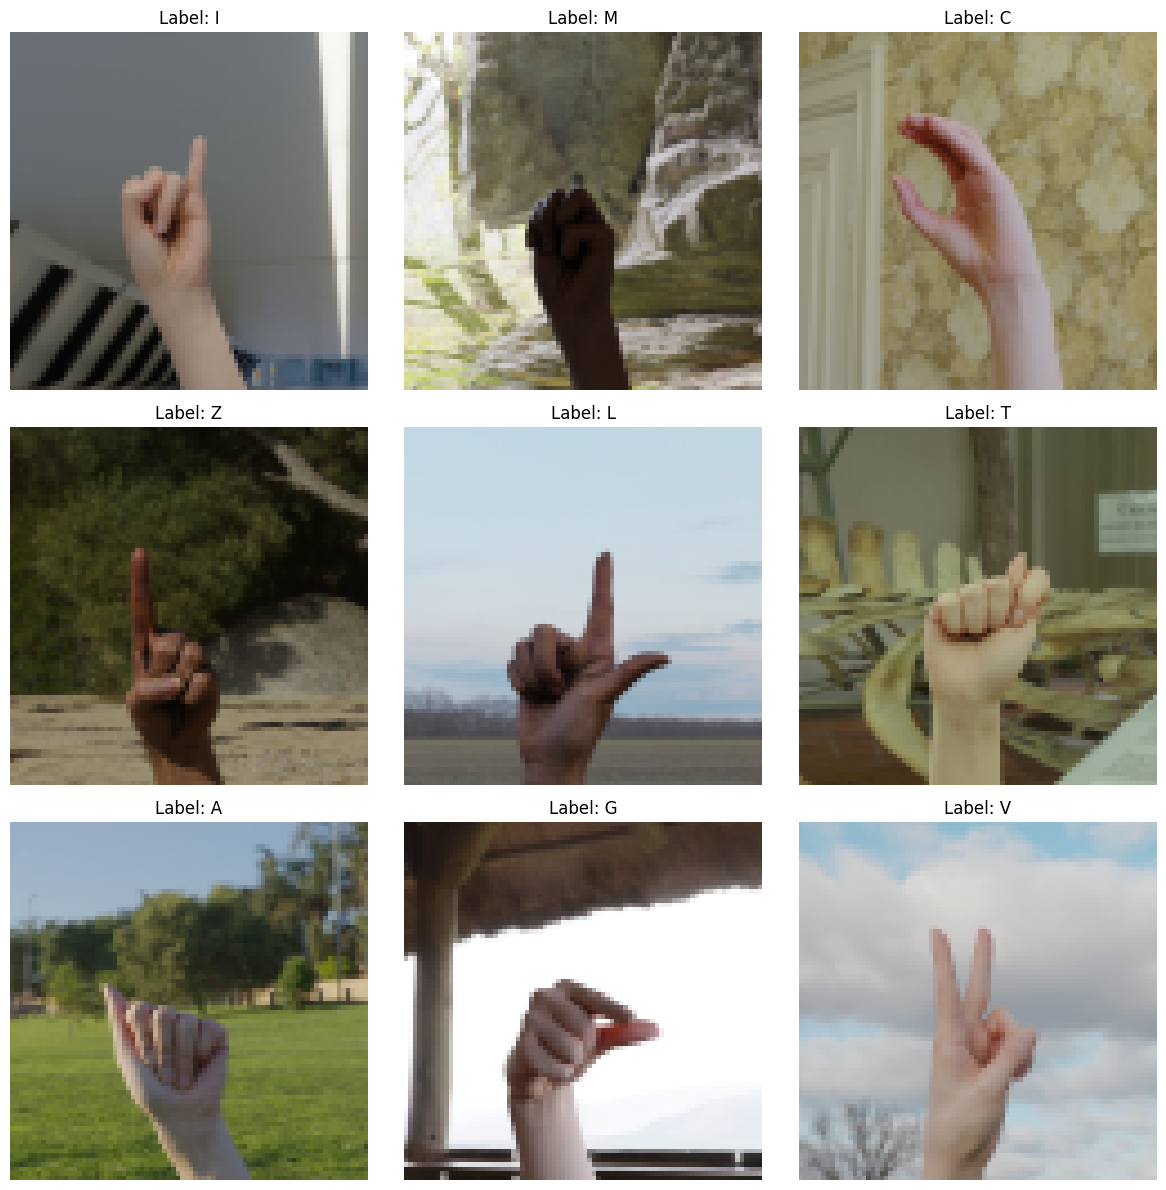

In [4]:
num_samples = 9
random_indices = random.sample(range(len(X)), num_samples)
plt.figure(figsize=(12, 12))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    
    img = X[idx]
    label = Y[idx] 
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Making copies of data

In [5]:
X_data=np.array(X)
Y_data=np.array(Y)

## One hot encoding of the dataset Labels

In [6]:
le=LabelEncoder()
Y_integers=le.fit_transform(Y_data)
num_classes=len(le.classes_)

y_onehot=to_categorical(Y_integers,num_classes=num_classes)

print("One-Hot shape:", y_onehot.shape)
print("Example conversion:")
print(f"Original: {Y_data[0]}")
print(f"Integer:  {Y_integers[0]}")
print(f"One-Hot:  {y_onehot[0]}")

One-Hot shape: (26000, 26)
Example conversion:
Original: A
Integer:  0
One-Hot:  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


## Splitting our X and Y lists into train,validation and test

In [7]:
x_train, x_test, y_train, y_test = train_test_split(X_data, y_onehot, test_size=0.2, random_state=42)

In [8]:
print(f"Train: {x_train.shape}, {y_train.shape}")
print(f"Test: {x_test.shape}, {y_test.shape}")

Train: (20800, 80, 80, 3), (20800, 26)
Test: (5200, 80, 80, 3), (5200, 26)


In [9]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [10]:
print(f"After split - Train: {x_train.shape}, {y_train.shape}")
print(f"Validation: {x_val.shape}, {y_val.shape}")

After split - Train: (16640, 80, 80, 3), (16640, 26)
Validation: (4160, 80, 80, 3), (4160, 26)


## Building Model 3 (changed the Baseline to: 80X80 resulution, reduced number of neurons on the layers and dropout of 0.5 on the classification layer)

In [11]:
from keras.layers import BatchNormalization

model = Sequential()

# Block 1
model.add(Conv2D(16, (3, 3), padding='same', input_shape=(80, 80, 3))) 
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2)))

# Block 2
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D((2, 2)))

# Block 3
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu')) 

model.add(MaxPooling2D((2, 2)))

# ... Flatten and Dense layers ...
model.add(Flatten())
model.add(Dense(128))
model.add(Activation('relu'))             
model.add(Dropout(0.5))          
model.add(Dense(26, activation='softmax'))  

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 80, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 846,266 (3.23 MB)

 Trainable params: 846,266 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

## Defining early stop 

In [12]:
early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

## Compiling and training the model

In [13]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
print("\nStarting training... monitoring Validation Accuracy only.")
history = model.fit(
    x_train, y_train, batch_size=32,
    epochs=30, 
    validation_data=(x_val, y_val), 
    verbose=1,
    callbacks=[early_stop]
)


Starting training... monitoring Validation Accuracy only.
Epoch 1/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.2859 - loss: 2.3763 - val_accuracy: 0.8031 - val_loss: 0.7168
Epoch 2/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.7439 - loss: 0.7946 - val_accuracy: 0.9137 - val_loss: 0.3346
Epoch 3/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.8460 - loss: 0.4705 - val_accuracy: 0.9387 - val_loss: 0.2279
Epoch 4/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.8901 - loss: 0.3311 - val_accuracy: 0.9486 - val_loss: 0.1697
Epoch 5/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.9145 - loss: 0.2535 - val_accuracy: 0.9611 - val_loss: 0.1214
Epoch 6/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.9312 - loss: 0.2022 - val_accuracy: 0.9613 - val_loss: 0.1080
Epoch 7/30
520/520 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.9461 - loss: 0.1614 - val_accuracy: 0.9688 - val_loss: 0.0888
Epoch 8/30
520/520 ━━━━━━━━━━━━

## Graph showing accuracy and loss of validation data compared to training data

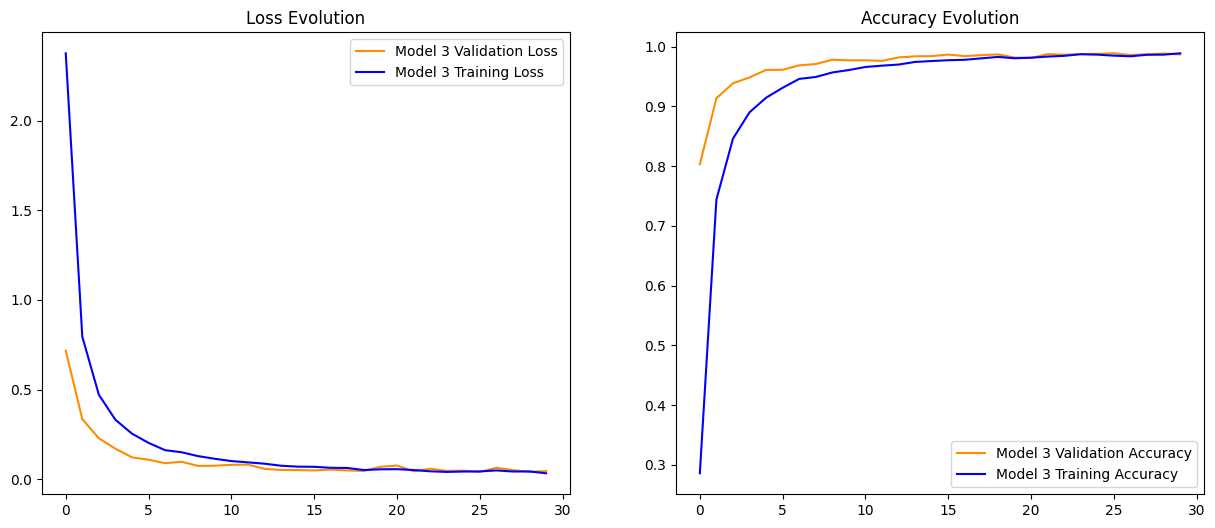

In [15]:
plt.figure(figsize=(15,6))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model.history.history['val_loss'], label='Model 3 Validation Loss', color='darkorange')
plt.plot(model.history.history['loss'], label='Model 3 Training Loss', color='blue')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(model.history.history['val_accuracy'], label='Model 3 Validation Accuracy', color='darkorange')
plt.plot(model.history.history['accuracy'], label='Model 3 Training Accuracy', color='blue')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

## Evaluating on test and showing its results

In [16]:
res=model.evaluate(x_test, y_test, verbose=2)
print(f"Test Set Evaluation: Loss = {res[0]:.4f}, Accuracy = {res[1]*100:.2f}%")

163/163 - 2s - 14ms/step - accuracy: 0.9852 - loss: 0.0609
Test Set Evaluation: Loss = 0.0609, Accuracy = 98.52%


## Showcasing 3 picture from the test the model classify correctly and 3 that were not

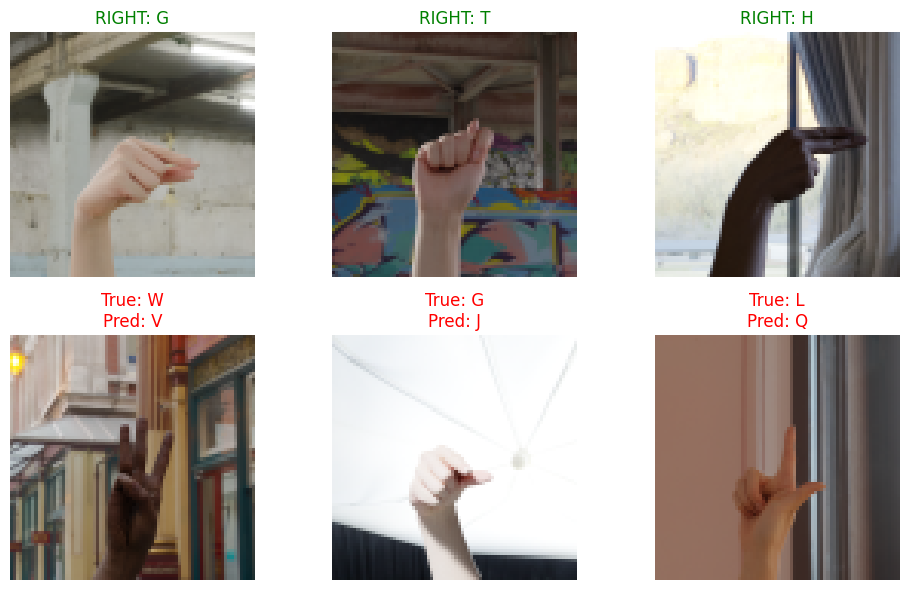

In [17]:
def show_3_right_3_wrong(model, X_test, y_test, class_names):

    y_true = np.argmax(y_test, axis=1)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    right_indices = np.where(y_true == y_pred)[0]
    wrong_indices = np.where(y_true != y_pred)[0]

    num_samples = 3
    
    if len(right_indices) >= num_samples:
        right_samples = np.random.choice(right_indices, num_samples, replace=False)
    else:
        right_samples = right_indices 

 
    if len(wrong_indices) >= num_samples:
        wrong_samples = np.random.choice(wrong_indices, num_samples, replace=False)
    else:
        wrong_samples = wrong_indices

    plt.figure(figsize=(10, 6))

 
    for i, idx in enumerate(right_samples):
        plt.subplot(2, 3, i + 1)
        plt.imshow(X_test[idx])
        plt.title(f"RIGHT: {class_names[y_true[idx]]}", color='green', fontsize=12)
        plt.axis("off")


    for i, idx in enumerate(wrong_samples):
        plt.subplot(2, 3, 3 + i + 1) 
        plt.imshow(X_test[idx])
        plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", color='red', fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Run the function
class_names = le.classes_
show_3_right_3_wrong(model, x_test, y_test, class_names)

## Classification report of the model and confusion matrix

In [18]:
y_true = np.argmax(y_test, axis=1) 
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
class_names = le.classes_

In [19]:
print("--- Classification Report ---\n")
print(metrics.classification_report(y_true, y_pred, target_names=class_names))

--- Classification Report ---

              precision    recall  f1-score   support

           A       0.98      1.00      0.99       191
           B       0.98      1.00      0.99       182
           C       1.00      1.00      1.00       218
           D       0.98      0.99      0.99       219
           E       0.99      0.99      0.99       195
           F       0.97      0.99      0.98       191
           G       1.00      0.97      0.98       230
           H       0.97      0.98      0.98       192
           I       0.99      1.00      1.00       212
           J       1.00      0.93      0.96       214
           K       1.00      1.00      1.00       209
           L       1.00      0.99      0.99       213
           M       0.99      0.99      0.99       221
           N       0.98      0.94      0.96       187
           O       1.00      0.98      0.99       195
           P       0.98      0.99      0.98       194
           Q       0.91      0.99      0.95       

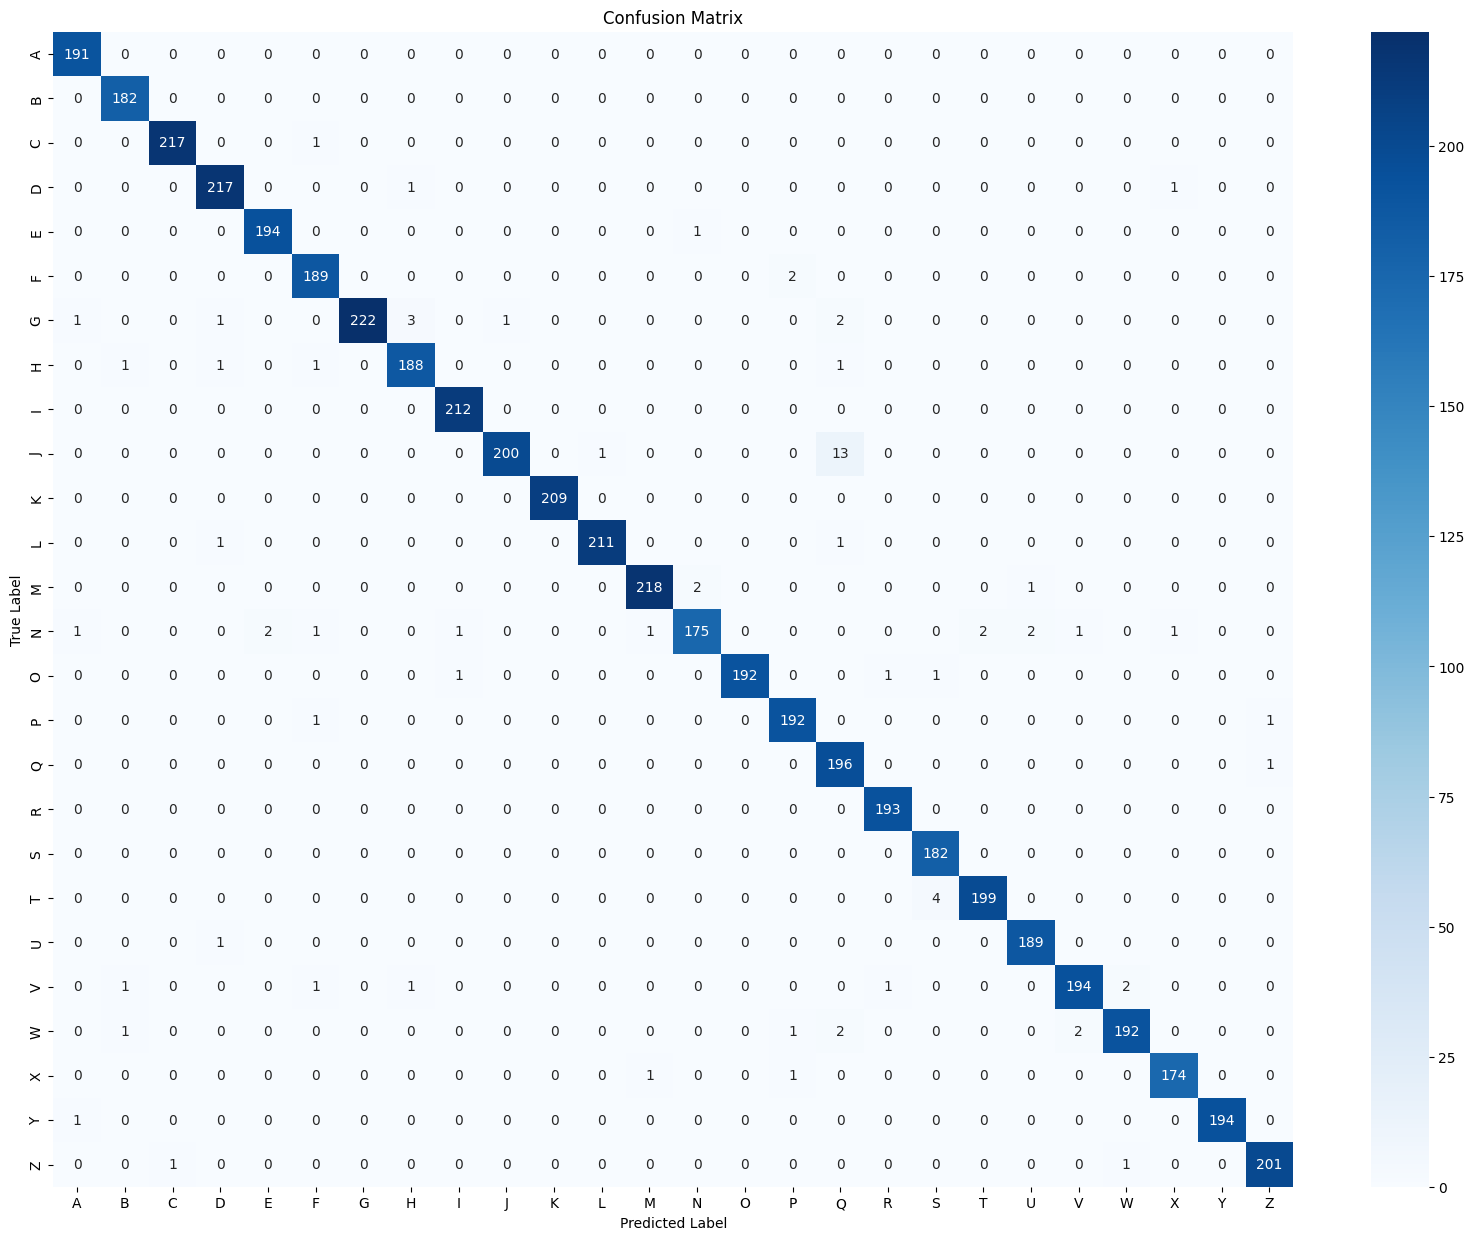

In [20]:
matrix=metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20,15))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
